## 분석 주제
**배송 지연 예측 기반 고객 만족도 관리 시스템**

## 주요 질문
**"배송 서비스 품질을 높여서 고객 만족도 관리를 할 수 있을까?"**

In [47]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import numpy as np

from scipy import stats
from scipy.stats import skew, kurtosis

from unidecode import unidecode
import geopandas as gpd
import sys
import os

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None) # 모든 컬럼이 다 보인다.
pd.set_option('display.max_rows', 100) # 행 출력 개수 제한

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [48]:
df_preprocess = pd.read_csv("../data/olist_preprocess_ver2_data.csv")


In [49]:
df_preprocess.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_payment_value,review_id,review_score,review_creation_date,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11 00:00:00,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46,8d5266042046a06655c8db133d120ba5,4.0,2018-08-08 00:00:00,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,2018-08-18 00:00:00,420.0,24.0,19.0,21.0,14840.0,guariba,SP,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20,359d03e676b3c069f62cadba8dd3f6e8,5.0,2017-12-03 00:00:00,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62,e50934924e227544ba8246aeb3770dd4,5.0,2018-02-17 00:00:00,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,stationery


### 배송 예측 시간이 애초에 길어서 오는 문제점도 있을듯?
- 예상 배송일 - 구매 날짜 => 며칠 소요

In [50]:
df_preprocess['order_estimated_delivery_date'].info()
df_preprocess['order_purchase_timestamp'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 111495 entries, 0 to 111494
Series name: order_estimated_delivery_date
Non-Null Count   Dtype 
--------------   ----- 
111495 non-null  object
dtypes: object(1)
memory usage: 871.2+ KB
<class 'pandas.core.series.Series'>
RangeIndex: 111495 entries, 0 to 111494
Series name: order_purchase_timestamp
Non-Null Count   Dtype 
--------------   ----- 
111495 non-null  object
dtypes: object(1)
memory usage: 871.2+ KB


- object type이라 datetime으로 변환이 필요

In [51]:
df_preprocess['order_estimated_delivery_date'] = pd.to_datetime(df_preprocess['order_estimated_delivery_date'])
df_preprocess['order_purchase_timestamp'] = pd.to_datetime(df_preprocess['order_purchase_timestamp'])

df_preprocess['order_estimated_delivery_date'].info()
df_preprocess['order_purchase_timestamp'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 111495 entries, 0 to 111494
Series name: order_estimated_delivery_date
Non-Null Count   Dtype         
--------------   -----         
111495 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 871.2 KB
<class 'pandas.core.series.Series'>
RangeIndex: 111495 entries, 0 to 111494
Series name: order_purchase_timestamp
Non-Null Count   Dtype         
--------------   -----         
111495 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 871.2 KB


- datetime으로 변환 확인 함.

## 파생변수 생성

In [52]:
df_preprocess['order_estimated_day_diff'] = df_preprocess['order_estimated_delivery_date']-df_preprocess['order_purchase_timestamp']
df_preprocess['order_estimated_day_diff'] = df_preprocess['order_estimated_day_diff'].dt.days

In [53]:
df_preprocess.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_payment_value,review_id,review_score,review_creation_date,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,order_estimated_day_diff
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11 00:00:00,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares,15
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46,8d5266042046a06655c8db133d120ba5,4.0,2018-08-08 00:00:00,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,perfumery,19
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,2018-08-18 00:00:00,420.0,24.0,19.0,21.0,14840.0,guariba,SP,auto,26
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20,359d03e676b3c069f62cadba8dd3f6e8,5.0,2017-12-03 00:00:00,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,pet_shop,26
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62,e50934924e227544ba8246aeb3770dd4,5.0,2018-02-17 00:00:00,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,stationery,12


In [54]:
df_preprocess['order_estimated_day_diff'].value_counts().sort_index()

order_estimated_day_diff
1        1
2      212
3      158
4      368
5      333
      ... 
142      1
144      1
146      1
149      2
155      1
Name: count, Length: 103, dtype: int64

- 100일이 훌쩍 넘는 건들도 존재한다. 시각화를 해볼까?

<Axes: xlabel='order_estimated_day_diff', ylabel='Count'>

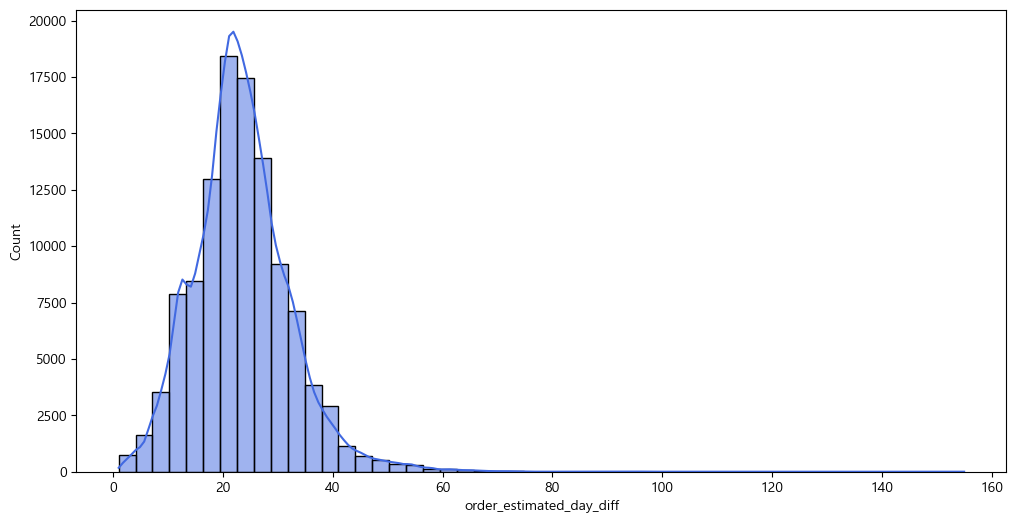

In [55]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_preprocess, x='order_estimated_day_diff',
             bins=50,
             color='royalblue',
             kde=True
             )


- 예를들어 예상 배송일이 100일이라면, 99일에 받았다면 이는 지연이 아닌데, 만족도가 높진 않을듯
- 근데 애초에, 예상 배송일이 100일인게 말이 됨? 실제로 배달이 얼마나 걸리는지를 한번 보자.

### 실제 배송일이 얼만지 한번 보자.
- 실제 배송까지 걸린 시간 = 배송 받은 날짜(order_delivered_customer_date) - 배송 시작 날짜(order_delivered_carrier_date? order_approved_at? order_purcahse_timestamp?)
- order_delivered_carrier_date(물류파트너에게 전달된 시점) / order_approved_at(결제 승인된 날짜/시간) / order_purcahse_timestamp(고객이 구매한 날짜/시간)

- 배송 시작 날짜를 정할 필요가 있긴 할 듯 => order_purchase_timestamp로 결정!! 실제 고객이 느끼는 배송의 총 시간이 중요하다고 생각!

In [56]:
df_preprocess['order_delivered_customer_date'].info()
df_preprocess['order_delivered_carrier_date'].info()
df_preprocess['order_approved_at'].info()
df_preprocess['order_purchase_timestamp'].info()


<class 'pandas.core.series.Series'>
RangeIndex: 111495 entries, 0 to 111494
Series name: order_delivered_customer_date
Non-Null Count   Dtype 
--------------   ----- 
111495 non-null  object
dtypes: object(1)
memory usage: 871.2+ KB
<class 'pandas.core.series.Series'>
RangeIndex: 111495 entries, 0 to 111494
Series name: order_delivered_carrier_date
Non-Null Count   Dtype 
--------------   ----- 
111495 non-null  object
dtypes: object(1)
memory usage: 871.2+ KB
<class 'pandas.core.series.Series'>
RangeIndex: 111495 entries, 0 to 111494
Series name: order_approved_at
Non-Null Count   Dtype 
--------------   ----- 
111495 non-null  object
dtypes: object(1)
memory usage: 871.2+ KB
<class 'pandas.core.series.Series'>
RangeIndex: 111495 entries, 0 to 111494
Series name: order_purchase_timestamp
Non-Null Count   Dtype         
--------------   -----         
111495 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 871.2 KB


In [57]:
df_preprocess['order_delivered_customer_date'] = pd.to_datetime(df_preprocess['order_delivered_customer_date'])
df_preprocess['order_delivered_carrier_date'] = pd.to_datetime(df_preprocess['order_delivered_carrier_date'])
df_preprocess['order_approved_at'] = pd.to_datetime(df_preprocess['order_approved_at'])

df_preprocess['order_estimated_delivery_date'].info()
df_preprocess['order_purchase_timestamp'].info()
df_preprocess['order_approved_at'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 111495 entries, 0 to 111494
Series name: order_estimated_delivery_date
Non-Null Count   Dtype         
--------------   -----         
111495 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 871.2 KB
<class 'pandas.core.series.Series'>
RangeIndex: 111495 entries, 0 to 111494
Series name: order_purchase_timestamp
Non-Null Count   Dtype         
--------------   -----         
111495 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 871.2 KB
<class 'pandas.core.series.Series'>
RangeIndex: 111495 entries, 0 to 111494
Series name: order_approved_at
Non-Null Count   Dtype         
--------------   -----         
111495 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 871.2 KB


In [58]:
df_preprocess['real_delivery_day'] = df_preprocess['order_delivered_customer_date'] - df_preprocess['order_purchase_timestamp']
df_preprocess['real_delivery_day'] = df_preprocess['real_delivery_day'].dt.days

In [59]:
df_preprocess['real_delivery_day'].value_counts().sort_index()

real_delivery_day
0          18
1        1806
2        3629
3        4371
4        5565
         ... 
30038       6
30040       1
30059       1
30067       1
30068       2
Name: count, Length: 692, dtype: int64

<Axes: xlabel='real_delivery_day', ylabel='Count'>

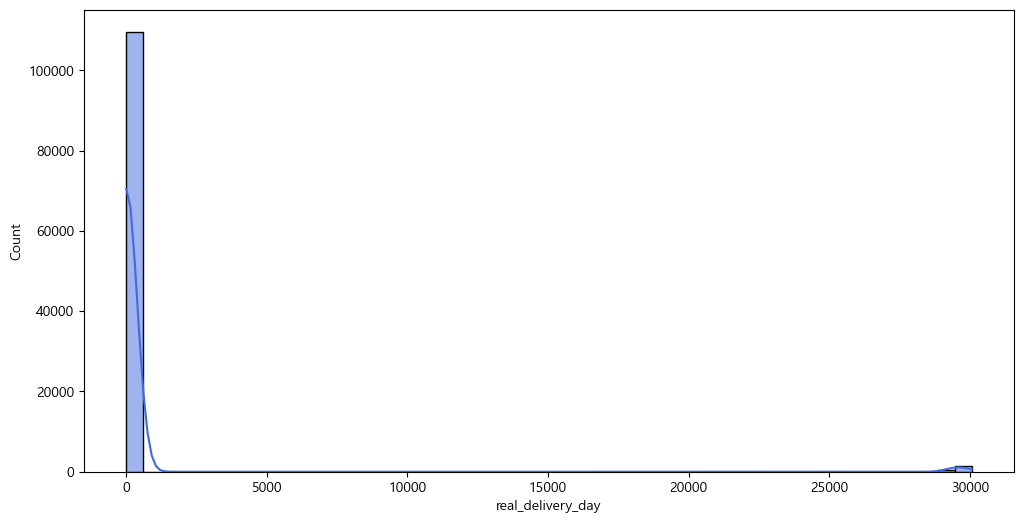

In [60]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_preprocess, x='real_delivery_day',
             bins=50,
             color='royalblue',
             kde=True
             )


<Axes: xlabel='real_delivery_day'>

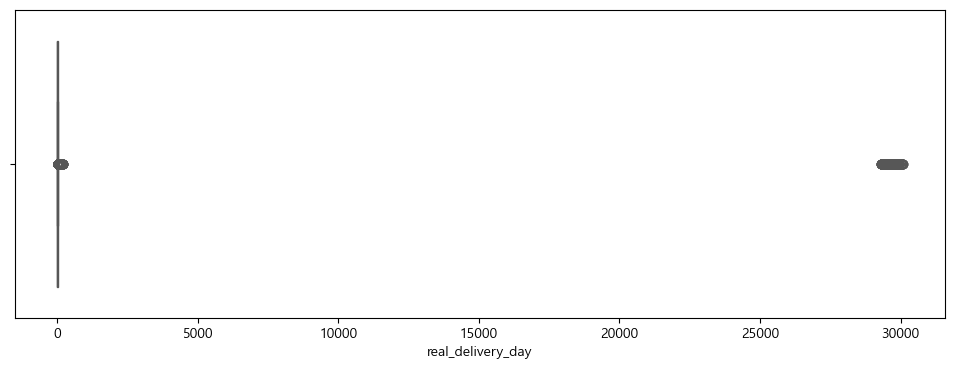

In [61]:
# boxplot
plt.figure(figsize=(12, 4))

sns.boxplot(data=df_preprocess, 
            x='real_delivery_day',
            color='royalblue'
            )

### 30000내외로 있는애들 이상함. 이상치로 판단하면 될듯!!!

# 오늘은 여기까지!

- 배송 지연? : late_delivery 컬럼 하나 만들면 좋을 듯
- 예측 시간 - 실제 배달 시간
- order_delivered_customer_date - order_estimated_delivery_date>1


# 단변량 분석